In [6]:
# Enable automatic reloading of imported modules
%load_ext autoreload
%autoreload 2

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import time

# Import from the engine
from l_vqe_engine import (
    build_maxcut_hamiltonian,
    best_known_maxcut_cost,
    simulate_one_lvqe
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


=== 1. MAX-CUT GRAPH SETUP & BASELINE ===


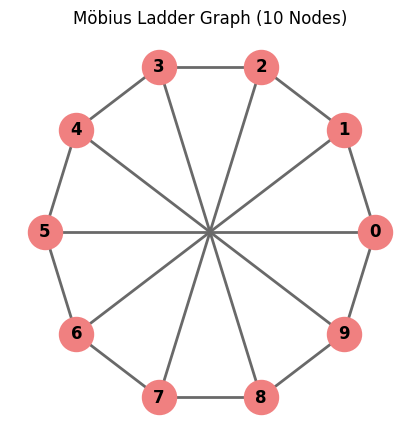

Calculating exact classical baseline...
True Maximum Cut (Negative Cost): -15.00
Total Qubits Required: 10


In [7]:
print("=== 1. MAX-CUT GRAPH SETUP & BASELINE ===")

def generate_mobius_ladder(n_nodes):
    """Generates a Möbius Ladder graph of n_nodes (must be even)."""
    assert n_nodes % 2 == 0, "Möbius ladder requires an even number of nodes."
    # Start with a standard ring (cycle graph)
    G = nx.cycle_graph(n_nodes)
    # Add the "rungs" across the opposite sides of the circle
    half = n_nodes // 2
    for i in range(half):
        G.add_edge(i, i + half)
    return G

# Generate the 10-node Möbius Ladder
n_nodes = 10
G_maxcut = generate_mobius_ladder(n_nodes)

# Visualize it
plt.figure(figsize=(4, 4))
pos = nx.circular_layout(G_maxcut) # Circular layout shows the cross-rungs beautifully
nx.draw(
    G_maxcut, 
    pos, 
    with_labels=True, 
    node_color='lightcoral', 
    edge_color='dimgray',
    width=2.0,
    font_weight='bold',
    node_size=600
)
plt.title(f"Möbius Ladder Graph ({n_nodes} Nodes)")
plt.show()

# Calculate absolute true baseline
print("Calculating exact classical baseline...")
true_maxcut_val = best_known_maxcut_cost(G_maxcut)
print(f"True Maximum Cut (Negative Cost): {true_maxcut_val:.2f}")
print(f"Total Qubits Required: {n_nodes}")

In [8]:
# =============================================================
# SECTION: ENTANGLEMENT VS NO ENTANGLEMENT
# =============================================================

print("=== ENTANGLEMENT VS NO ENTANGLEMENT (Max-Cut) ===")

H_mc = build_maxcut_hamiltonian(G_maxcut)

n_seeds = 10
mc_ent_results = {"entanglement": [], "no_entanglement": []}
rows = []

for seed in range(n_seeds):
    print(f"\nSeed {seed+1}/{n_seeds}")

    rng = np.random.default_rng(seed)
    t0 = time.time()
    res_ent = simulate_one_lvqe(
        n_q=n_nodes,
        H=H_mc,
        max_layers=1,
        shots=None,
        max_iter_per_layer=600,
        rng=rng,
        optimizer="SMO",
        no_entanglement=False
    )
    t_ent = time.time() - t0
    rho_ent = res_ent['final_cost'] / true_maxcut_val
    mc_ent_results["entanglement"].append(rho_ent)
    print(f"  With entanglement    → ρ = {rho_ent:.4f}  ({t_ent:.1f}s)")

    rows.append({
        "Algorithm": "L-VQE Entanglement",
        "Nodes":     n_nodes,
        "Seed":      seed,
        "p_or_L":    1,
        "Rho":       rho_ent,
        "Time_s":    t_ent,
    })

    rng = np.random.default_rng(seed)
    t0 = time.time()
    res_no = simulate_one_lvqe(
        n_q=n_nodes,
        H=H_mc,
        max_layers=1,
        shots=None,
        max_iter_per_layer=600,
        rng=rng,
        optimizer="SMO",
        no_entanglement=True
    )
    t_no = time.time() - t0
    rho_no = res_no['final_cost'] / true_maxcut_val
    mc_ent_results["no_entanglement"].append(rho_no)
    print(f"  Without entanglement → ρ = {rho_no:.4f}  ({t_no:.1f}s)")

    rows.append({
        "Algorithm": "L-VQE No Entanglement",
        "Nodes":     n_nodes,
        "Seed":      seed,
        "p_or_L":    1,
        "Rho":       rho_no,
        "Time_s":    t_no,
    })

df_ent_maxcut = pd.DataFrame(rows)
df_ent_maxcut.to_csv("data_entanglement_maxcut.csv", index=False)
print(f"\nSaved to data_entanglement_maxcut.csv")
print(df_ent_maxcut.to_string(index=False))

print("\n" + "="*55)
print("SUMMARY")
print("="*55)
for label, rhos in mc_ent_results.items():
    rhos_arr = np.array(rhos)
    print(f"\n{label}:")
    print(f"  best  = {rhos_arr.max():.4f}")
    print(f"  mean  = {rhos_arr.mean():.4f} ± {rhos_arr.std():.4f}")
    print(f"  >0.99 = {(rhos_arr > 0.99).mean()*100:.1f}%")
    print(f"  >0.95 = {(rhos_arr > 0.95).mean()*100:.1f}%")
    print(f"  >0.90 = {(rhos_arr > 0.90).mean()*100:.1f}%")

=== ENTANGLEMENT VS NO ENTANGLEMENT (Max-Cut) ===

Seed 1/10
  Layer 0  (10 params) ... cost = -15.000000
  Layer 1  (46 params) ... cost = -15.000000
  With entanglement    → ρ = 1.0000  (5.3s)
  Layer 0  (10 params) ... cost = -15.000000
  Layer 1  (46 params) ... cost = -15.000000
  Without entanglement → ρ = 1.0000  (5.2s)

Seed 2/10
  Layer 0  (10 params) ... cost = -11.000000
  Layer 1  (46 params) ... cost = -15.000000
  With entanglement    → ρ = 1.0000  (5.7s)
  Layer 0  (10 params) ... cost = -11.000000
  Layer 1  (46 params) ... cost = -11.000000
  Without entanglement → ρ = 0.7333  (5.6s)

Seed 3/10
  Layer 0  (10 params) ... cost = -11.000000
  Layer 1  (46 params) ... cost = -15.000000
  With entanglement    → ρ = 1.0000  (5.3s)
  Layer 0  (10 params) ... cost = -11.000000
  Layer 1  (46 params) ... cost = -11.000000
  Without entanglement → ρ = 0.7333  (5.0s)

Seed 4/10
  Layer 0  (10 params) ... cost = -15.000000
  Layer 1  (46 params) ... cost = -15.000000
  With entan

=== Finite shots experiment ===

In [11]:
for seed in range(n_seeds):
    print(f"\nSeed {seed+1}/{n_seeds}")

    rng = np.random.default_rng(seed)
    res_ent = simulate_one_lvqe(
        n_q=n_nodes,
        H=H_mc,
        max_layers=1,
        shots=1000,
        max_iter_per_layer=600,
        rng=rng,
        optimizer="SMO",
        no_entanglement=False
    )
    rho_ent = res_ent['final_cost'] / true_maxcut_val
    print(f"  With entanglement    → ρ = {rho_ent:.4f}")
    rows.append({"Algorithm": "L-VQE Entanglement",
                 "Nodes": n_nodes, "Seed": seed,
                 "p_or_L": 1, "Rho": rho_ent})

    rng = np.random.default_rng(seed)
    res_no = simulate_one_lvqe(
        n_q=n_nodes,
        H=H_mc,
        max_layers=1,
        shots=1000,
        max_iter_per_layer=600,
        rng=rng,
        optimizer="SMO",
        no_entanglement=True
    )
    rho_no = res_no['final_cost'] / true_maxcut_val
    print(f"  Without entanglement → ρ = {rho_no:.4f}")
    rows.append({"Algorithm": "L-VQE No Entanglement",
                 "Nodes": n_nodes, "Seed": seed,
                 "p_or_L": 1, "Rho": rho_no})

df = pd.DataFrame(rows)
df['Rho'] = df['Rho'].clip(upper=1.0)
df.to_csv("data_entanglement_maxcut_shots1000.csv", index=False)
print("\nDone. Saved to data_entanglement_maxcut_shots1000.csv")

for label in ["L-VQE Entanglement", "L-VQE No Entanglement"]:
    rhos = df[df["Algorithm"] == label]["Rho"].values
    print(f"\n{label}:")
    print(f"  mean = {rhos.mean():.4f} ± {rhos.std():.4f}")
    print(f"  >0.99 = {(rhos > 0.99).mean()*100:.1f}%")
    print(f"  >0.95 = {(rhos > 0.95).mean()*100:.1f}%")
    print(f"  >0.90 = {(rhos > 0.90).mean()*100:.1f}%")


Seed 1/10
  Layer 0  (10 params) ... 

/Users/ayseidilevci/layered_vqe/venv/lib/python3.12/site-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


cost = -15.000000
  Layer 1  (46 params) ... cost = -14.997000
  With entanglement    → ρ = 0.9996
  Layer 0  (10 params) ... cost = -14.997000
  Layer 1  (46 params) ... cost = -15.000000
  Without entanglement → ρ = 0.9998

Seed 2/10
  Layer 0  (10 params) ... cost = -10.999000
  Layer 1  (46 params) ... cost = -14.990000
  With entanglement    → ρ = 0.9998
  Layer 0  (10 params) ... cost = -10.999000
  Layer 1  (46 params) ... cost = -10.992000
  Without entanglement → ρ = 0.7330

Seed 3/10
  Layer 0  (10 params) ... cost = -10.999000
  Layer 1  (46 params) ... cost = -14.989000
  With entanglement    → ρ = 0.9993
  Layer 0  (10 params) ... cost = -11.000000
  Layer 1  (46 params) ... cost = -10.999000
  Without entanglement → ρ = 0.7333

Seed 4/10
  Layer 0  (10 params) ... cost = -14.997000
  Layer 1  (46 params) ... cost = -15.000000
  With entanglement    → ρ = 0.9993
  Layer 0  (10 params) ... cost = -14.988000
  Layer 1  (46 params) ... cost = -14.994000
  Without entanglement

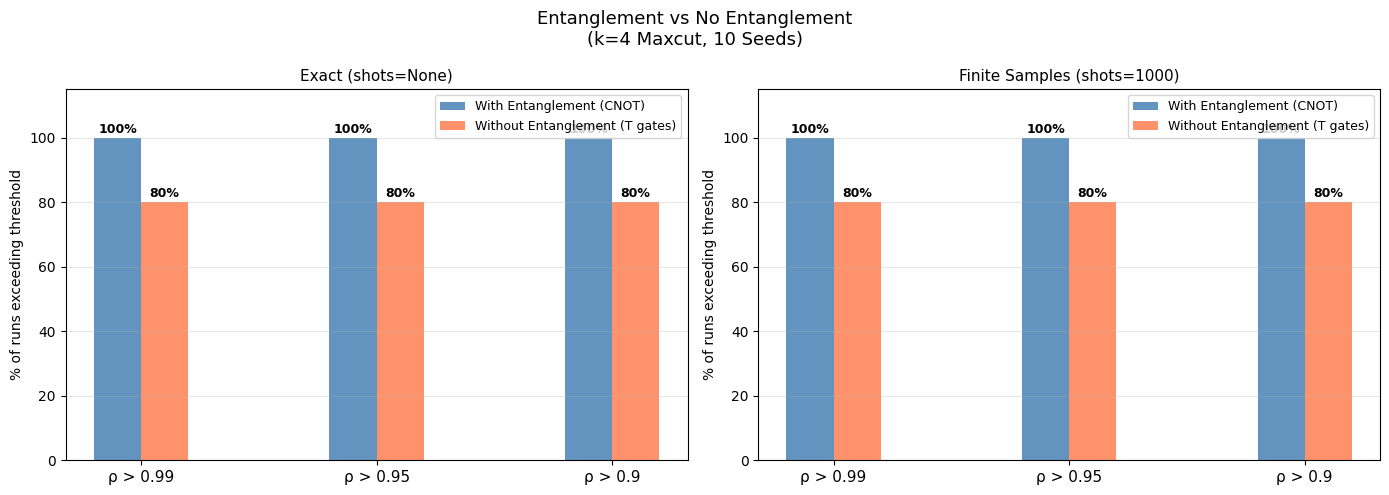

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load both datasets
df_shots = pd.read_csv("data_entanglement_maxcut_shots1000.csv")
df_exact = pd.read_csv("data_entanglement_maxcut.csv")
df_exact['Rho'] = df_exact['Rho'].clip(upper=1.0)
df_shots['Rho'] = df_shots['Rho'].clip(upper=1.0)

ent_exact = df_exact[df_exact["Algorithm"] == "L-VQE Entanglement"]["Rho"].values
no_exact  = df_exact[df_exact["Algorithm"] == "L-VQE No Entanglement"]["Rho"].values
ent_shots = df_shots[df_shots["Algorithm"] == "L-VQE Entanglement"]["Rho"].values
no_shots  = df_shots[df_shots["Algorithm"] == "L-VQE No Entanglement"]["Rho"].values

thresholds = [0.99, 0.95, 0.90]
x = np.arange(len(thresholds))
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Entanglement vs No Entanglement\n(k=4 Maxcut, 10 Seeds)", fontsize=13)

for ax, ent, no, title in zip(
    axes,
    [ent_exact, ent_shots],
    [no_exact, no_shots],
    ["Exact (shots=None)", "Finite Samples (shots=1000)"]
):
    ent_pct = [(ent > t).mean() * 100 for t in thresholds]
    no_pct  = [(no  > t).mean() * 100 for t in thresholds]

    bars_ent = ax.bar(x - width/2, ent_pct, width,
                      label="With Entanglement (CNOT)",
                      color="steelblue", alpha=0.85)
    bars_no  = ax.bar(x + width/2, no_pct,  width,
                      label="Without Entanglement (T gates)",
                      color="coral", alpha=0.85)

    for bar in bars_ent:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1.5,
                f"{bar.get_height():.0f}%",
                ha='center', fontsize=9, fontweight='bold')
    for bar in bars_no:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1.5,
                f"{bar.get_height():.0f}%",
                ha='center', fontsize=9, fontweight='bold')

    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels([f"ρ > {t}" for t in thresholds], fontsize=11)
    ax.set_ylabel("% of runs exceeding threshold", fontsize=10)
    ax.set_ylim(0, 115)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("entanglement_maxcut_bar_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

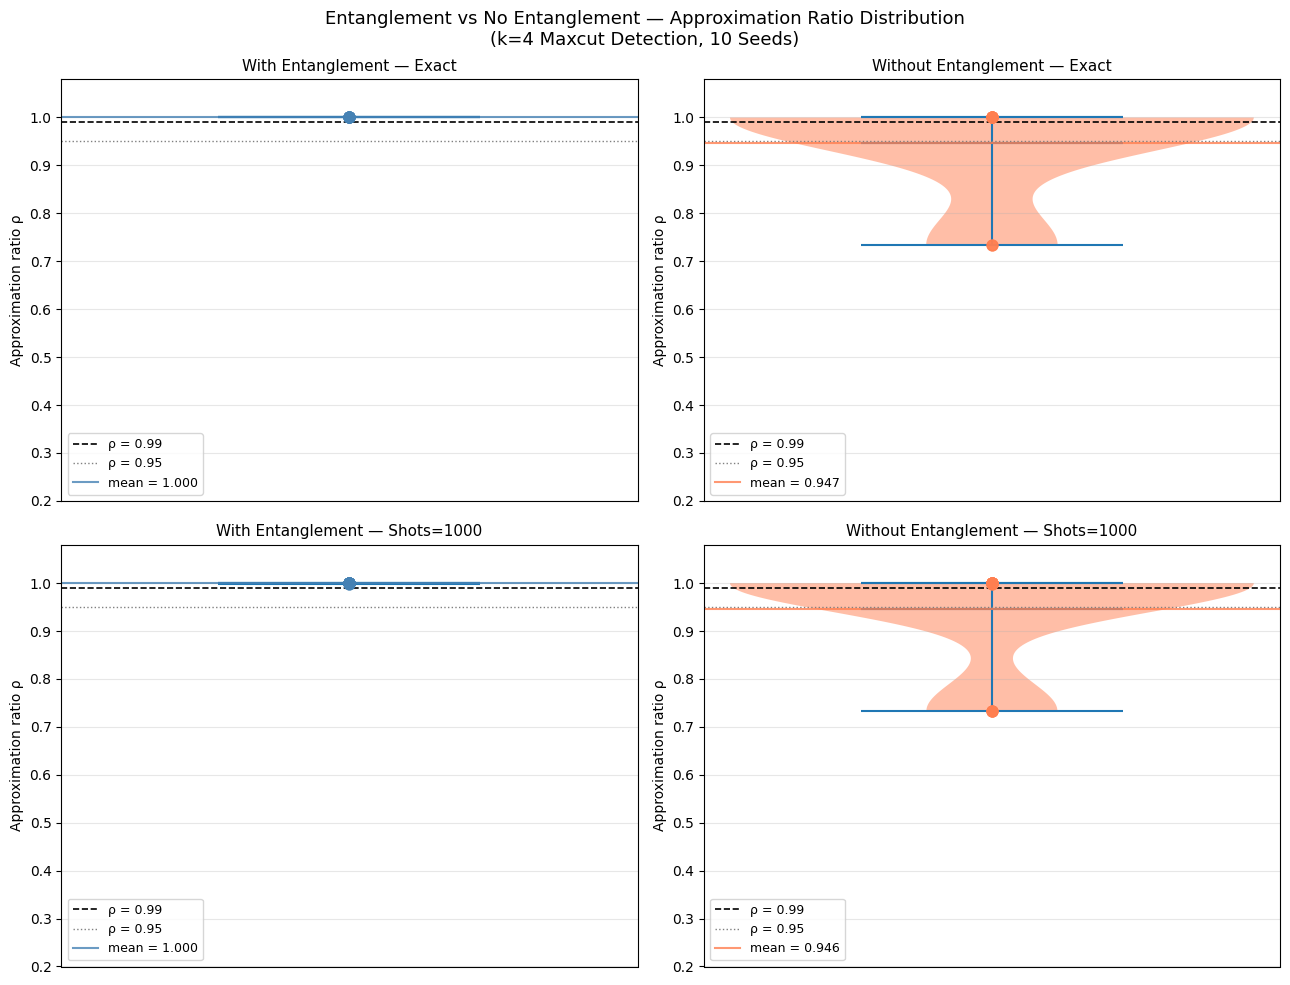

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Entanglement vs No Entanglement — Approximation Ratio Distribution\n"
             "(k=4 Maxcut Detection, 10 Seeds)", fontsize=13)

datasets = [
    (ent_exact, "steelblue", "With Entanglement — Exact"),
    (no_exact,  "coral",     "Without Entanglement — Exact"),
    (ent_shots, "steelblue", "With Entanglement — Shots=1000"),
    (no_shots,  "coral",     "Without Entanglement — Shots=1000"),
]

for ax, (rhos, color, title) in zip(axes.flatten(), datasets):
    vp = ax.violinplot([rhos], positions=[1], showmeans=True, showmedians=True)
    for body in vp['bodies']:
        body.set_facecolor(color)
        body.set_alpha(0.5)

    ax.scatter([1]*len(rhos), rhos, color=color, alpha=0.8, s=60, zorder=3)
    ax.axhline(0.99, color="black", linestyle="--", linewidth=1.2, label="ρ = 0.99")
    ax.axhline(0.95, color="gray",  linestyle=":",  linewidth=1.0, label="ρ = 0.95")
    ax.axhline(rhos.mean(), color=color, linestyle="-",
               linewidth=1.5, alpha=0.8, label=f"mean = {rhos.mean():.3f}")

    ax.set_title(title, fontsize=11)
    ax.set_xticks([])
    ax.set_ylabel("Approximation ratio ρ", fontsize=10)
    ax.set_ylim(0.2, 1.08)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("entanglement_maxcut_violin_comparison.png", dpi=150, bbox_inches='tight')
plt.show()